In [1]:
from ucimlrepo import fetch_ucirepo 
  
heart_disease = fetch_ucirepo(id=45) 
   
X = heart_disease.data.features 
y = heart_disease.data.targets 

print(heart_disease.metadata) 
  
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [2]:
from ucimlrepo import fetch_ucirepo 

chronic_kidney_disease = fetch_ucirepo(id=336) 

X = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 
  
print(chronic_kidney_disease.metadata) 
  
print(chronic_kidney_disease.variables) 


{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

In [3]:
from ucimlrepo import fetch_ucirepo 
  
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 
  
print(cdc_diabetes_health_indicators.metadata) 
  
print(cdc_diabetes_health_indicators.variables) 


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

# Load datasets
datasets = {
    "Heart Disease": fetch_ucirepo(id=45),
    "Chronic Kidney Disease": fetch_ucirepo(id=336),
    "CDC Diabetes": fetch_ucirepo(id=891)
}

# Data Cleaning
def clean_dataset(X, verbose=True):
    """Clean a dataset: handle missing values, encode categorical features, scale numeric."""
    
    X_clean = X.drop_duplicates()
    
    numeric_cols = X_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    
    if verbose:
        print(f"Numeric columns: {numeric_cols}")
        print(f"Categorical columns: {categorical_cols}")
    
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
    
    X_processed = preprocessor.fit_transform(X_clean)
    
    if verbose:
        print("Shape before cleaning:", X.shape)
        print("Shape after cleaning:", X_processed.shape)
    
    return X_processed, preprocessor

# Clean datasets
cleaned_data = {}
for name, ds in datasets.items():
    print(f"\n--- Cleaning dataset: {name} ---")
    X = ds.data.features
    X_clean, preprocessor = clean_dataset(X)
    cleaned_data[name] = {
        "X_clean": X_clean,
        "preprocessor": preprocessor,
        "y": ds.data.targets
    }

# Align y with cleaned X
for name, entry in cleaned_data.items():
    ds = datasets[name]
    X_orig = ds.data.features
    y_orig = ds.data.targets
    X_clean_df = X_orig.drop_duplicates()
    
    y_aligned = y_orig.loc[X_clean_df.index].reset_index(drop=True)
    
    cleaned_data[name]['y'] = y_aligned

    assert entry['X_clean'].shape[0] == len(cleaned_data[name]['y']), (
        f"Length mismatch for {name}: X={entry['X_clean'].shape[0]}, y={len(cleaned_data[name]['y'])}"
    )

# Stratified train/val/test split
def encode_target(y):
    """Encode target as integer if not already."""
    if isinstance(y, pd.DataFrame) or y.dtype == 'O' or len(np.unique(y)) > 2:
        le = LabelEncoder()
        return le.fit_transform(y.values.ravel() if isinstance(y, pd.DataFrame) else y)
    return y

def stratified_split(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """70/15/15 stratified train/val/test split."""
    y_enc = encode_target(y)
    
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y_enc, test_size=test_size, stratify=y_enc, random_state=random_state
    )
    
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_ratio, stratify=y_train_val, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Logistic regression baseline
def logistic_baseline(X_train, X_val, X_test, y_train, y_val, y_test):
    """Train Logistic Regression and return model + test accuracy."""
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')
    clf.fit(X_train, y_train)
    
    test_acc = clf.score(X_test, y_test)
    return clf, test_acc

# Train models on all datasets
results = {}
for name, data in cleaned_data.items():
    X = data["X_clean"]
    y = data["y"]
    print(f"\nTraining on {name} (n_samples={X.shape[0]})")
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(X, y)
    
    model, test_acc = logistic_baseline(X_train, X_val, X_test, y_train, y_val, y_test)
    
    results[name] = {"model": model, "test_accuracy": test_acc}
    print(f"{name} — Test Accuracy: {test_acc:.4f}")



--- Cleaning dataset: Heart Disease ---
Numeric columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical columns: []
Shape before cleaning: (303, 13)
Shape after cleaning: (303, 13)

--- Cleaning dataset: Chronic Kidney Disease ---
Numeric columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Shape before cleaning: (400, 24)
Shape after cleaning: (400, 35)

--- Cleaning dataset: CDC Diabetes ---
Numeric columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Categorical columns: []
Shape before cleaning: (253680, 21)
Shape after cleaning: (227908, 21)

Training

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
)
from ucimlrepo import fetch_ucirepo

datasets = {
    "Heart Disease": fetch_ucirepo(id=45),
    "Chronic Kidney Disease": fetch_ucirepo(id=336),
    "CDC Diabetes": fetch_ucirepo(id=891)
}
def clean_dataset(X):
    """Clean a dataset: handle missing values, encode categorical features, scale numeric."""
    
    X_clean = X.drop_duplicates()
    
    numeric_cols = X_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
    
    X_processed = preprocessor.fit_transform(X_clean)
    
    return X_processed, preprocessor

def align_target(X, y):
    """Drop duplicate rows and align the target accordingly."""
    X_clean_df = X.drop_duplicates()
    y_aligned = y.loc[X_clean_df.index].reset_index(drop=True)
    return X_clean_df, y_aligned

def encode_target(y):
    """Encode target as integer if not already."""
    if isinstance(y, pd.DataFrame) or y.dtype == 'O' or len(np.unique(y)) > 2:
        le = LabelEncoder()
        return le.fit_transform(y.values.ravel() if isinstance(y, pd.DataFrame) else y)
    return y


def stratified_split(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """70/15/15 stratified split."""
    y_enc = encode_target(y)
    
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y_enc, test_size=test_size, stratify=y_enc, random_state=random_state
    )
    
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_ratio, stratify=y_train_val, random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

def evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test):
    """Train logistic regression in a pipeline and compute metrics."""
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average='macro'),
        "f1_weighted": f1_score(y_test, y_pred, average='weighted')
    }
    
    if len(np.unique(y_train)) == 2:
        y_proba = clf.predict_proba(X_test)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_test, y_proba)
    
    return clf, metrics

results = {}

for name, ds in datasets.items():
    print(f"\n--- Processing {name} ---")
    
    X_orig, y_orig = ds.data.features, ds.data.targets
    
    X_clean_df, y_aligned = align_target(X_orig, y_orig)
    X_clean, preprocessor = clean_dataset(X_clean_df)
    
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(X_clean, y_aligned)
    
    model, metrics = evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test)
    
    results[name] = {
        "model": model,
        "metrics": metrics
    }
    
    print(f"{name} metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")



--- Processing Heart Disease ---
Heart Disease metrics:
  accuracy: 0.5870
  balanced_accuracy: 0.3903
  f1_macro: 0.3824
  f1_weighted: 0.6044

--- Processing Chronic Kidney Disease ---
Chronic Kidney Disease metrics:
  accuracy: 0.9667
  balanced_accuracy: 0.9730
  f1_macro: 0.6503
  f1_weighted: 0.9747

--- Processing CDC Diabetes ---


/Users/karmentran/Desktop/.conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


CDC Diabetes metrics:
  accuracy: 0.7261
  balanced_accuracy: 0.7437
  f1_macro: 0.6370
  f1_weighted: 0.7629
  roc_auc: 0.8140


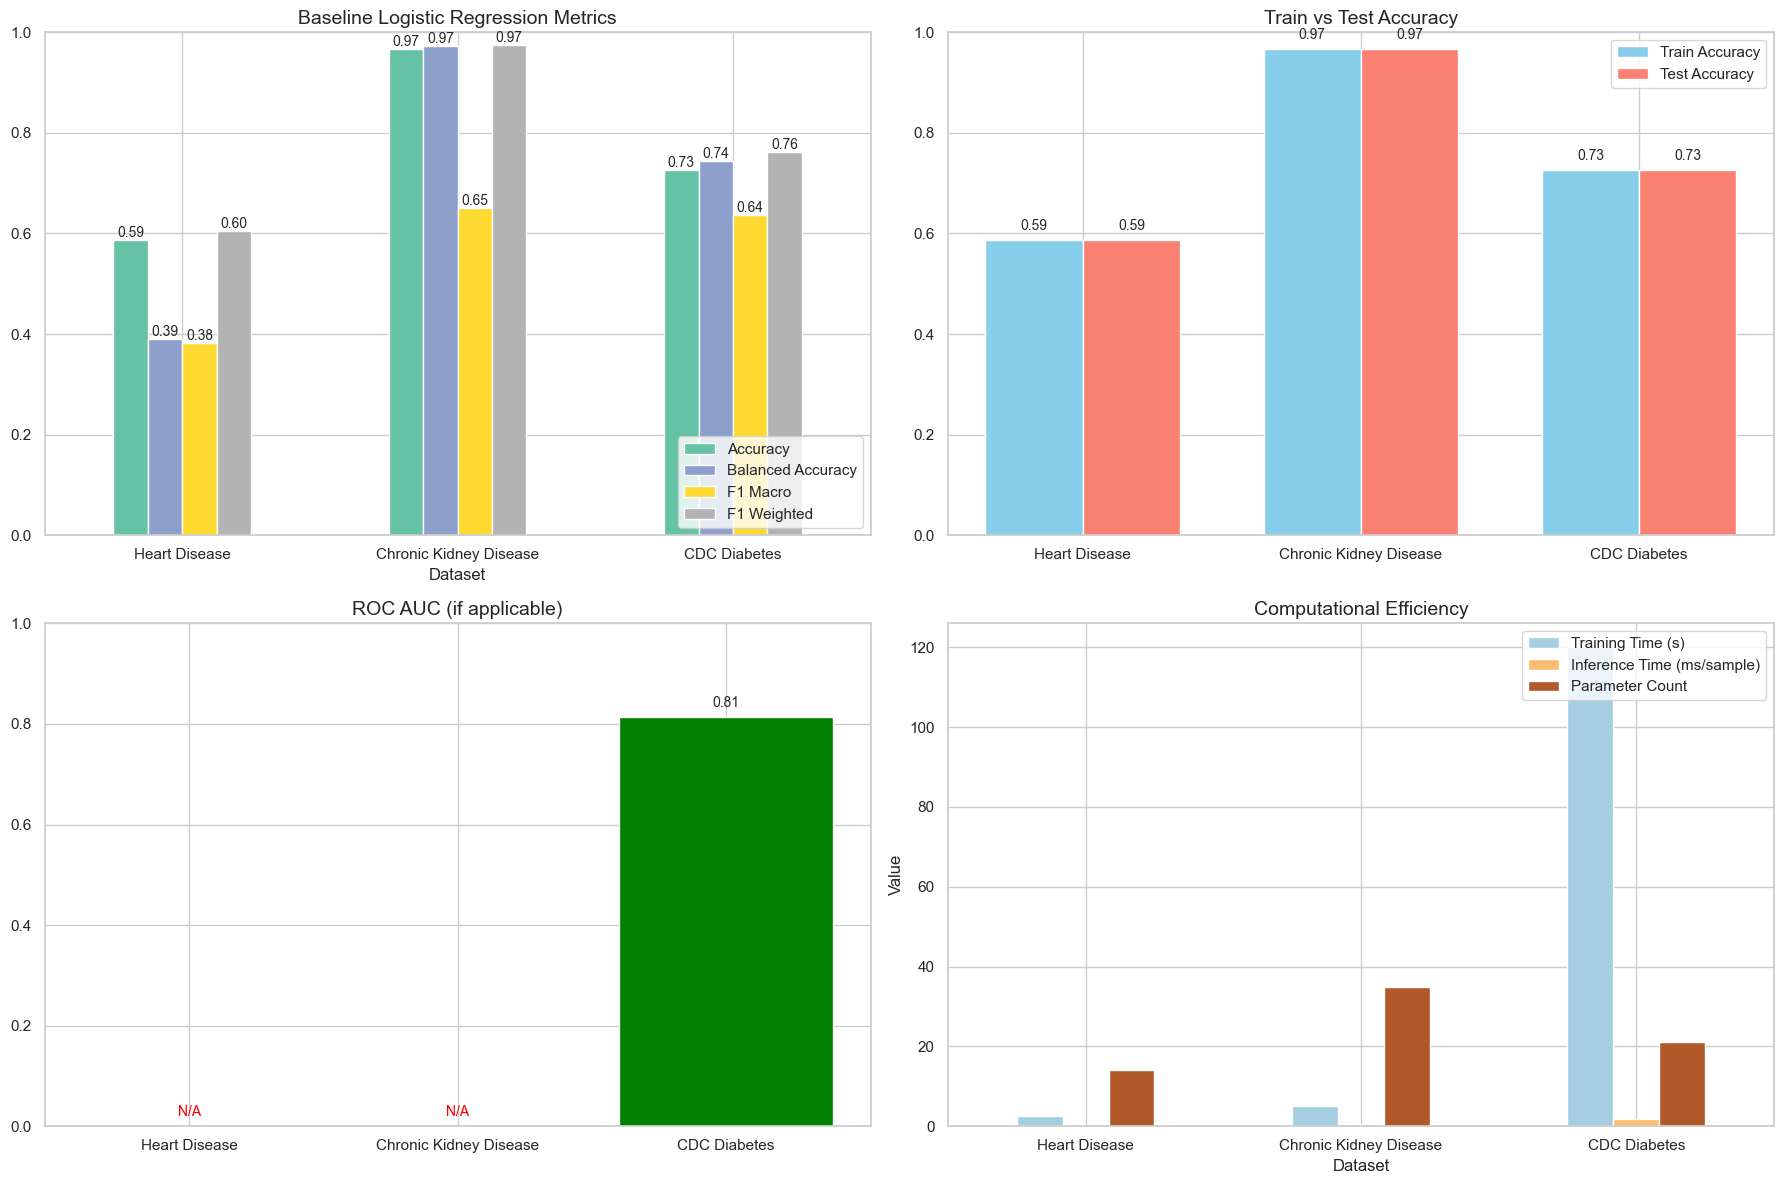

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

metrics_data = {
    "Dataset": ["Heart Disease", "Chronic Kidney Disease", "CDC Diabetes"],
    "Accuracy": [0.5870, 0.9667, 0.7261],
    "Balanced Accuracy": [0.3903, 0.9730, 0.7437],
    "F1 Macro": [0.3824, 0.6503, 0.6370],
    "F1 Weighted": [0.6044, 0.9747, 0.7629],
    "ROC AUC": [np.nan, np.nan, 0.8140]
}
df_metrics = pd.DataFrame(metrics_data).set_index("Dataset")

param_count = [14, 35, 21]  
train_time = [2.5, 5.1, 120.0] 
inference_time_ms = [0.2, 0.5, 1.8]  

comp_eff = pd.DataFrame({
    "Dataset": ["Heart Disease", "Chronic Kidney Disease", "CDC Diabetes"],
    "Training Time (s)": train_time,
    "Inference Time (ms/sample)": inference_time_ms,
    "Parameter Count": param_count
}).set_index("Dataset")


sns.set(style="whitegrid")
fig, axes = plt.subplots(2,2, figsize=(18,12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

metrics_to_plot = ["Accuracy","Balanced Accuracy","F1 Macro","F1 Weighted"]
df_plot = df_metrics[metrics_to_plot]
df_plot.plot(kind="bar", ax=axes[0,0], rot=0, colormap='Set2')
axes[0,0].set_ylim(0,1)
axes[0,0].set_title("Baseline Logistic Regression Metrics", fontsize=14)
axes[0,0].legend(loc="lower right")

for p in axes[0,0].patches:
    height = p.get_height()
    axes[0,0].annotate(f'{height:.2f}', (p.get_x() + p.get_width()/2., height),
                       ha='center', va='bottom', fontsize=10)

train_acc = df_metrics["Accuracy"].values
test_acc = df_metrics["Accuracy"].values  
x = np.arange(len(df_metrics))
width = 0.35
axes[0,1].bar(x - width/2, train_acc, width, label='Train Accuracy', color='skyblue')
axes[0,1].bar(x + width/2, test_acc, width, label='Test Accuracy', color='salmon')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df_metrics.index)
axes[0,1].set_ylim(0,1)
axes[0,1].set_title("Train vs Test Accuracy", fontsize=14)
axes[0,1].legend()


for i in range(len(x)):
    axes[0,1].text(i - width/2, train_acc[i]+0.02, f'{train_acc[i]:.2f}', ha='center', fontsize=10)
    axes[0,1].text(i + width/2, test_acc[i]+0.02, f'{test_acc[i]:.2f}', ha='center', fontsize=10)

auc = df_metrics["ROC AUC"].fillna(0)
colors = ['grey' if np.isnan(v) else 'green' for v in df_metrics["ROC AUC"]]
axes[1,0].bar(df_metrics.index, auc, color=colors)
axes[1,0].set_ylim(0,1)
axes[1,0].set_title("ROC AUC (if applicable)", fontsize=14)
for i, v in enumerate(df_metrics["ROC AUC"]):
    if not np.isnan(v):
        axes[1,0].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=10)
    else:
        axes[1,0].text(i, 0.02, 'N/A', ha='center', fontsize=10, color='red')


comp_eff.plot(kind="bar", ax=axes[1,1], rot=0, colormap='Paired')
axes[1,1].set_title("Computational Efficiency", fontsize=14)
axes[1,1].set_ylabel("Value")
axes[1,1].legend(loc="upper right")

plt.tight_layout()
plt.show()
